In [1170]:
#how does proximity to financial services, age, home ownership, education level, and employment affect household income.

In [1171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
import scipy.stats as st
import statsmodels.api as sm 
import pylab as py 

# here are some of the tools we will use for our analyses
from sklearn.linear_model import LinearRegression
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

import itertools
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression

from sklearn.impute import SimpleImputer
from functools import partial
from sklearn.model_selection import \
     (cross_validate,
      KFold,
      ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier  # optional GAM substitute if needed
import numpy as np
import csv
import sqlite3
from pygam import LogisticGAM

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report



In [1172]:
income = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Household Income.csv", na_values=['NA'])
prox_bank = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Prox_bank_csv.csv", na_values=['NA'])
employment = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Employment.csv", na_values=['NA'])
#job_density = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Job_Density_csv.csv", na_values=['NA'])
#pop_density = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Population_Density_csv.csv", na_values=['NA'])
education = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Education Level - Bachelor's Degree.csv", na_values=['NA'])
age = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\Age_csv.csv", na_values=['NA'])
home_owner = pd.read_csv(r"C:\Users\addis\Downloads\DTSC\home_owner_csv.csv", na_values=['NA'])

In [1173]:
conn = sqlite3.connect("my_data.db")

income.to_sql("income", conn, if_exists="replace", index=False)
prox_bank.to_sql("prox_bank", conn, if_exists="replace", index=False)
employment.to_sql("employment", conn, if_exists="replace", index=False)
education.to_sql("education", conn, if_exists="replace", index=False) 
age.to_sql("age", conn, if_exists="replace", index=False)
home_owner.to_sql("home_owner", conn, if_exists="replace", index=False)

459

In [1174]:
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE income(
    NPA INT PRIMARY KEY,
    median_income DOUBLE
)
""")

cursor.execute("""
CREATE TABLE prox_bank(
    NPA INTEGER,
    "2023" DOUBLE
)
""")

cursor.execute("""
CREATE TABLE employment(
    NPA INTEGER,
    employment_rate DOUBLE
)
""")

cursor.execute("""
CREATE TABLE education(
    NPA INTEGER,
    bachelors_percent DOUBLE
)
""")
cursor.execute("""
CREATE TABLE age(
    NPA INTEGER,
    median_age DOUBLE
)
""")
cursor.execute("""
CREATE TABLE home_owner(
    NPA INTEGER,
    home_owner_percent DOUBLE
    )
    """)

In [1175]:
for _, row in income.iterrows():
    cursor.execute("INSERT INTO income VALUES (?, ?)",
                   (row['NPA'], row['2023']))

for _, row in prox_bank.iterrows():
    cursor.execute("INSERT INTO prox_bank VALUES (?, ?)", 
                   (row['NPA'], row['2023']))

for _, row in employment.iterrows():
    cursor.execute("INSERT INTO employment VALUES (?, ?)", 
                   (row['NPA'], row['2023']))

for _, row in education.iterrows():
    cursor.execute("INSERT INTO education VALUES (?, ?)", 
                   (row['NPA'], row['2023']))
for _, row in age.iterrows():
    cursor.execute("INSERT INTO age VALUES (?, ?)", 
                   (row['NPA'], row['2023']))
for _, row in home_owner.iterrows():
    cursor.execute("INSERT INTO home_owner VALUES (?, ?)", 
                   (row['NPA'], row['2023']))

In [1176]:
def clean_npa(df):
    df['NPA'] = (
        df['NPA']
        .astype(str)
        .str.strip()
        .str.replace(r'\.0$', '', regex=True)
    )
    return df

income = clean_npa(income)
prox_bank = clean_npa(prox_bank)
employment = clean_npa(employment)
age = clean_npa(age)
home_owner = clean_npa(home_owner)
education = clean_npa(education)

In [1177]:
query = """
SELECT 
    i.NPA,
    i.median_income AS income,
    pb."2023" AS prox_bank,
    e.employment_rate AS employment,
    ed.bachelors_percent,
    ag.median_age,
    ho.home_owner_percent
FROM income i
LEFT JOIN prox_bank pb 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(pb.NPA AS TEXT))
LEFT JOIN employment e 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(e.NPA AS TEXT))
LEFT JOIN education ed 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ed.NPA AS TEXT))
LEFT JOIN age ag 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ag.NPA AS TEXT))
LEFT JOIN home_owner ho 
    ON TRIM(CAST(i.NPA AS TEXT)) = TRIM(CAST(ho.NPA AS TEXT))
"""

result = pd.read_sql_query(query, conn)
print(result.head())
print(result.info())

   NPA    income prox_bank employment bachelors_percent median_age  \
0    2   75084.0     0.245      0.956             0.352       33.0   
1    3  117630.0       1.0      0.974             0.854       30.0   
2    4  250001.0     0.152      0.943             0.894       43.0   
3    5   49539.0      0.19      0.828             0.025       30.0   
4    6   37907.0     0.699        1.0              0.21       42.0   

  home_owner_percent  
0              0.403  
1              0.392  
2                1.0  
3              0.149  
4              0.373  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   NPA                 459 non-null    int64 
 1   income              459 non-null    object
 2   prox_bank           459 non-null    object
 3   employment          459 non-null    object
 4   bachelors_percent   459 non-null    object
 

In [1178]:
#Classification model starts here

In [1179]:
df = result.copy()

# target
df['income'] = pd.to_numeric(df['income'], errors='coerce')
df['high_income'] = (df['income'] > df['income'].median()).astype(int)

In [1180]:
X = df[['prox_bank', 'employment', 'bachelors_percent', 'median_age', 'home_owner_percent']]

# Target
y = df['high_income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=60
)

In [1181]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
#converts everything to numeric, and coercing errors to NaN

X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]


In [1182]:
tree = DecisionTreeClassifier(max_depth=5)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [1183]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

X_test = X_test.fillna(X_train.median())
y_pred_log = log_model.predict(X_test)

In [1184]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

In [1185]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [1186]:
from pygam import LogisticGAM

gam = LogisticGAM()
gam.fit(X_train, y_train)

y_pred_gam = gam.predict(X_test)

In [1187]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "kNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),   # helps kNN + LR + LDA by scaling
        ("model", model)
    ])

    scores = cross_val_score(pipe, X_numeric, y, cv=cv, scoring="accuracy")

    results[name] = {
        "mean_accuracy": np.mean(scores),
        "std": np.std(scores),
        "scores": scores
    }

for name, metrics in results.items():
    print(name)
    print(f"  Mean Accuracy: {metrics['mean_accuracy']:.4f}")
    print(f"  Std Dev:       {metrics['std']:.4f}")
    print()
    

Decision Tree
  Mean Accuracy: 0.7866
  Std Dev:       0.0291

Logistic Regression
  Mean Accuracy: 0.8409
  Std Dev:       0.0263

LDA
  Mean Accuracy: 0.8409
  Std Dev:       0.0263

kNN
  Mean Accuracy: 0.8214
  Std Dev:       0.0172



In [1188]:
print("""
Model Comparison:
-----------------
Decision Tree:      {}
Logistic Regression: {}
LDA:                {}
kNN:                {}
GAM:                {}
""".format(
    accuracy_score(y_test, y_pred_tree),
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_lda),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_gam)
))
#this is straight accuracy from the models. 
# Above we have cross-validated accuracy which is stronger.


Model Comparison:
-----------------
Decision Tree:      0.782608695652174
Logistic Regression: 0.8369565217391305
LDA:                0.8586956521739131
kNN:                0.6739130434782609
GAM:                0.8260869565217391



                 Model   F1 Mean  F1 Std Dev
2                  LDA  0.840674    0.026301
1  Logistic Regression  0.840538    0.026324
3                  kNN  0.821196    0.017291
0        Decision Tree  0.786301    0.029155


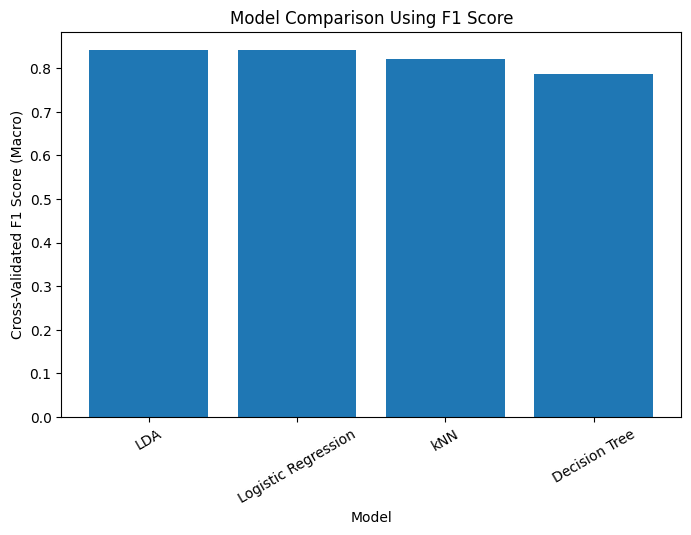

In [1189]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "kNN": KNeighborsClassifier()
}

names, means, stds = [], [], []

for name, model in models.items():
    
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    scores = cross_val_score(
        pipe,
        X_numeric,
        y,
        cv=cv,
        scoring="f1_macro"  
    )
    
    names.append(name)
    means.append(np.mean(scores))
    stds.append(np.std(scores))

# Create results table
df = pd.DataFrame({
    "Model": names,
    "F1 Mean": means,
    "F1 Std Dev": stds
}).sort_values("F1 Mean", ascending=False)

print(df)

# 📊 Plot
plt.figure(figsize=(8,5))
plt.bar(df["Model"], df["F1 Mean"])
plt.xlabel("Model")
plt.ylabel("Cross-Validated F1 Score (Macro)")
plt.title("Model Comparison Using F1 Score")
plt.xticks(rotation=30)
plt.show()

#high f1 + low std = best overall model

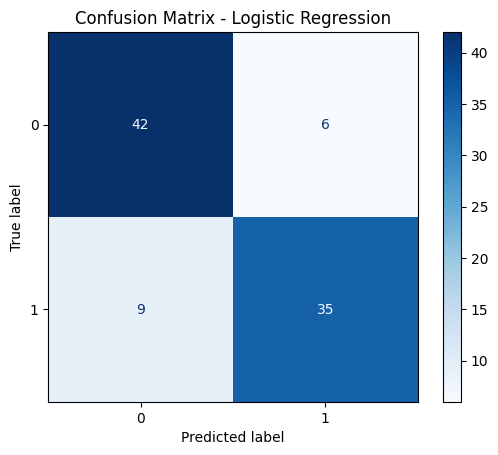

In [1190]:
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)

# Build model pipeline
model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

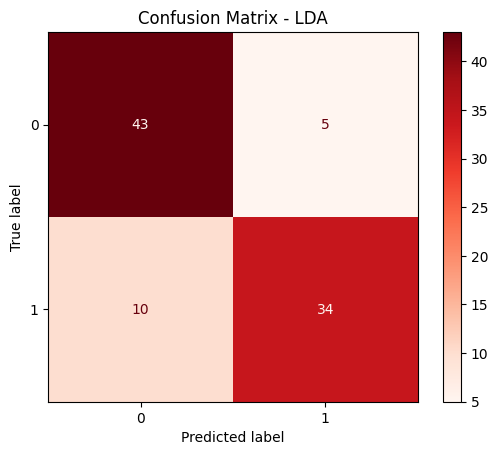

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        48
           1       0.87      0.77      0.82        44

    accuracy                           0.84        92
   macro avg       0.84      0.83      0.84        92
weighted avg       0.84      0.84      0.84        92



In [1191]:
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42, stratify=y
)


model = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis())
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Confusion Matrix - LDA")
plt.show()
print(classification_report(y_test, y_pred))